# Day2.5 — Why is B1 hard?

This notebook is a focused diagnostic follow-up to the Day2+ cross-board transfer stress test.

Previous Day2+ analyses showed that:

- B5 behaves like a drifted / broadened-domain target whose transfer error is strongly related to source-domain coverage.
- B1 behaves differently: high-concentration transfer error is severe, but source-volume and coverage metrics do not explain it well.
- Therefore B1 may represent a **target-intrinsic failure mode**, not merely a poor source-selection problem.

## Scientific question

**Why is B1 difficult as a transfer target?**

We test three possible mechanisms:

1. **Calibration bias** — predictions are systematically shifted.
2. **High-concentration response compression** — true 80–100 ppm samples are predicted as lower concentrations.
3. **Dynamic mismatch** — B1 has unusual response/recovery feature structure relative to other boards.

This notebook is intentionally diagnostic and exploratory. The dataset contains only five boards, so the goal is not formal statistical proof. The goal is to obtain mechanistic evidence that clarifies whether B1 failure is source-selection limited or target-side nonlinear.


In [1]:
from pathlib import Path
import sys
import itertools
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# Robust project-root detection. Expected notebook location:
# MOx_Calibration_Transfer/notebooks/day2_5_b1_failure_analysis.ipynb
CWD = Path.cwd().resolve()
if CWD.name == "notebooks":
    PROJECT_ROOT = CWD.parent
elif (CWD / "notebooks").exists() and (CWD / "src").exists():
    PROJECT_ROOT = CWD
else:
    # Fallback for external execution from inside /mnt/data/MOx_Calibration_Transfer/notebooks-like copies.
    PROJECT_ROOT = CWD if (CWD / "src").exists() else CWD.parent

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "figures" / "day2_5_b1_failure"
RESULT_DIR = PROJECT_ROOT / "results" / "day2_5_b1_failure"
DAY2PLUS_RESULT_DIR = PROJECT_ROOT / "results" / "day2plus"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
DAY2PLUS_RESULT_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)
print("DATA_DIR:", DATA_DIR)
print("FIG_DIR:", FIG_DIR)
print("RESULT_DIR:", RESULT_DIR)

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Missing src directory: {SRC_DIR}")


PROJECT_ROOT: C:\Users\hg\PycharmProjects\mox_calibration_transfer
SRC_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\src
DATA_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\data\raw
FIG_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure
RESULT_DIR: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2_5_b1_failure


In [2]:
from day2plus_transfer_matrix import (
    TARGET_GAS,
    RANDOM_STATE,
    assert_no_label_leakage,
    build_feature_table,
    get_feature_columns,
    evaluate_split,
)

PRIMARY_FEATURE_SET = "physics"
PRIMARY_MODEL = "RandomForest"
TARGETS_FOR_COMPARISON = ["B1", "B2", "B5"]
B1_SINGLE_SOURCES = ["B2", "B3", "B4", "B5"]
B1_KEY_FAILURE_SOURCES = ["B3", "B4", "B5"]

print("Gas:", TARGET_GAS)
print("Feature set:", PRIMARY_FEATURE_SET)
print("Model:", PRIMARY_MODEL)


Gas: GMe
Feature set: physics
Model: RandomForest


## 1. Load methane feature table

Feature extraction follows the same Day2/Day2+ pipeline. The leakage check is repeated here because this notebook trains transfer models again for diagnostic plots.


In [3]:
feature_cache = DAY2PLUS_RESULT_DIR / "day2plus_feature_table_GMe.csv"

if feature_cache.exists():
    df = pd.read_csv(feature_cache)
    print("Loaded cached feature table:", feature_cache)
else:
    if not DATA_DIR.exists():
        raise FileNotFoundError(
            f"Missing raw data directory: {DATA_DIR}. "
            "Run this notebook inside the MOx_Calibration_Transfer project, or place raw UCI txt files under data/raw/."
        )
    df = build_feature_table(DATA_DIR, gas=TARGET_GAS)
    df.to_csv(feature_cache, index=False)
    print("Built and cached feature table:", feature_cache)

feature_cols = get_feature_columns(df, PRIMARY_FEATURE_SET)
leakage_report = assert_no_label_leakage(df)

print("Feature table shape:", df.shape)
print("Boards:", sorted(df["board"].unique()))
print("Concentrations:", sorted(df["concentration_numeric"].unique()))
print("n physics features:", len(feature_cols))
print("Leakage check:", leakage_report[PRIMARY_FEATURE_SET])

display(df[["filename", "board", "gas", "concentration_code", "concentration_numeric", "replicate"]].head())


Loaded cached feature table: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2plus\day2plus_feature_table_GMe.csv
Feature table shape: (160, 126)
Boards: ['B1', 'B2', 'B3', 'B4', 'B5']
Concentrations: [np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100)]
n physics features: 71
Leakage check: {'n_features': 71, 'leakage_overlap': [], 'ok': True}


,filename,board,gas,concentration_code,concentration_numeric,replicate
0,B1_GMe_F010_R1.txt,B1,GMe,F010,10,R1
1,B1_GMe_F010_R2.txt,B1,GMe,F010,10,R2
2,B1_GMe_F010_R3.txt,B1,GMe,F010,10,R3
3,B1_GMe_F010_R4.txt,B1,GMe,F010,10,R4
4,B1_GMe_F020_R1.txt,B1,GMe,F020,20,R1


## 2. Build diagnostic prediction table

We generate predictions for all source combinations targeting B1, B2, and B5.

This serves two purposes:

1. B1 can be compared against a typical target (B2) and a drifted target (B5).
2. We can test whether B1 error decreases with more source boards, or whether it remains a target-side failure.


In [4]:
pred_csv = RESULT_DIR / "day2_5_target_predictions.csv"
metrics_csv = RESULT_DIR / "day2_5_target_metrics.csv"

if pred_csv.exists() and metrics_csv.exists():
    pred_df = pd.read_csv(pred_csv)
    metrics_df = pd.read_csv(metrics_csv)
    print("Loaded cached diagnostic predictions:", pred_csv)
else:
    boards = sorted(df["board"].unique())
    metric_rows = []
    pred_rows = []
    for target in TARGETS_FOR_COMPARISON:
        candidate_sources = [b for b in boards if b != target]
        for k in range(1, len(candidate_sources) + 1):
            for sources in itertools.combinations(candidate_sources, k):
                metrics, preds = evaluate_split(
                    df,
                    source_boards=list(sources),
                    target_board=target,
                    feature_set=PRIMARY_FEATURE_SET,
                    model_name=PRIMARY_MODEL,
                    random_state=RANDOM_STATE,
                )
                metric_rows.append(metrics)
                pred_rows.append(preds)
    metrics_df = pd.DataFrame(metric_rows)
    pred_df = pd.concat(pred_rows, ignore_index=True)
    metrics_df["source_count"] = metrics_df["source_boards"].str.split("+").str.len()
    pred_df["source_count"] = pred_df["source_boards"].str.split("+").str.len()
    pred_df["signed_error"] = pred_df["y_pred"] - pred_df["y_true"]
    metrics_df.to_csv(metrics_csv, index=False)
    pred_df.to_csv(pred_csv, index=False)
    print("Saved diagnostic metrics:", metrics_csv)
    print("Saved diagnostic predictions:", pred_csv)

print("metrics_df:", metrics_df.shape)
print("pred_df:", pred_df.shape)
display(metrics_df.sort_values("rmse", ascending=False).head(12))


Saved diagnostic metrics: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2_5_b1_failure\day2_5_target_metrics.csv
Saved diagnostic predictions: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2_5_b1_failure\day2_5_target_predictions.csv
metrics_df: (45, 12)
pred_df: (1500, 15)


,source_boards,n_source_boards,target_board,feature_set,model,n_train,n_test,rmse,mae,r2,includes_B5_source,source_count
2,B4,1,B1,physics,RandomForest,20,40,17.059493,12.948750,0.647241,False,1
7,B3+B4,2,B1,physics,RandomForest,60,40,13.946360,10.161250,0.764241,False,2
13,B3+B4+B5,3,B1,physics,RandomForest,80,40,13.942663,10.141250,0.764366,True,3
8,B3+B5,2,B1,physics,RandomForest,60,40,12.979962,9.661875,0.795783,True,2
3,B5,1,B1,physics,RandomForest,20,40,12.973678,9.587500,0.795980,True,1
1,B3,1,B1,physics,RandomForest,40,40,12.264505,8.894375,0.817675,False,1
9,B4+B5,2,B1,physics,RandomForest,40,40,11.720415,8.108750,0.833493,True,2
17,B4,1,B2,physics,RandomForest,20,40,11.204104,8.363750,0.847840,False,1
10,B2+B3+B4,3,B1,physics,RandomForest,100,40,10.589710,7.125625,0.864070,False,3
4,B2+B3,2,B1,physics,RandomForest,80,40,10.454833,7.156250,0.867511,False,2


## 3. Signed error diagnosis: bias or compression?

The most direct diagnostic is signed error:

\[
\mathrm{signed\ error} = \hat{y} - y
\]

- Negative signed error at high concentration means **systematic underestimation**.
- High-concentration underestimation with otherwise reasonable low-concentration behavior suggests **response compression**.
- Mixed positive/negative scatter suggests more of a variance or dynamics instability problem.

We compare B1 against B2 and B5 so that B1-specific behavior is not mistaken for a generic model artifact.


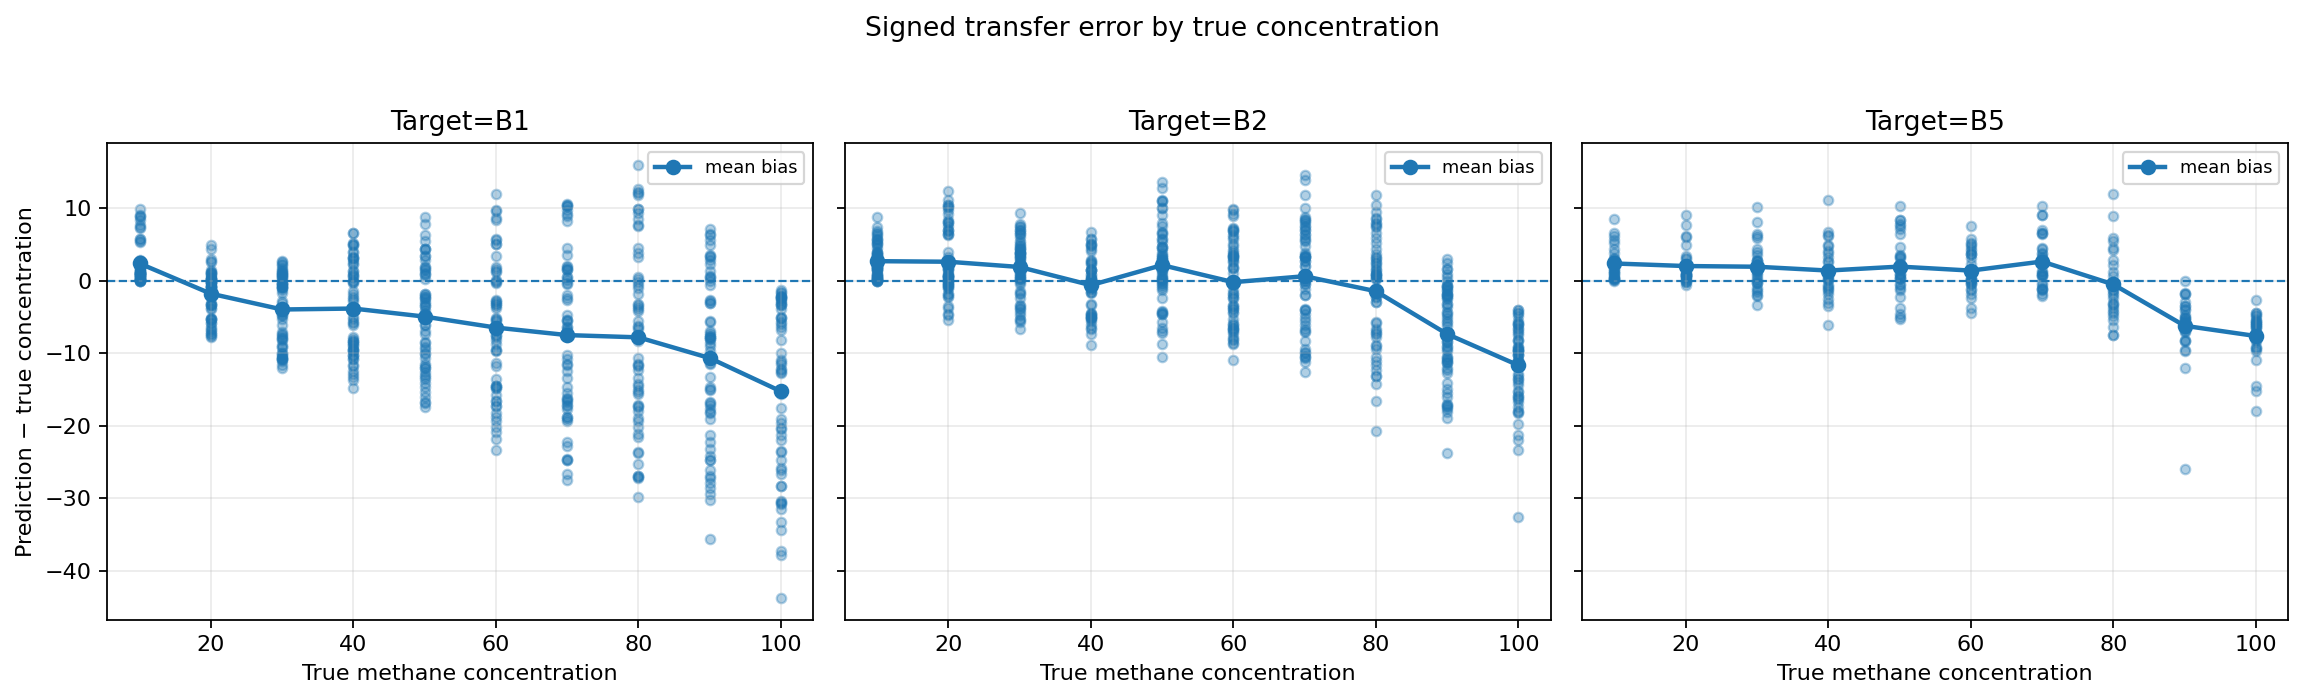

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\signed_error_vs_true_concentration_B1_B2_B5.png


In [5]:
def _scatter_signed_error_by_target(pred_df, path):
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), dpi=160, sharey=True)
    for ax, target in zip(axes, TARGETS_FOR_COMPARISON):
        tmp = pred_df[pred_df["target_board"] == target].copy()
        ax.scatter(tmp["y_true"], tmp["signed_error"], alpha=0.35, s=18)
        bias = tmp.groupby("y_true", as_index=False)["signed_error"].mean()
        ax.plot(bias["y_true"], bias["signed_error"], marker="o", linewidth=2, label="mean bias")
        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(f"Target={target}")
        ax.set_xlabel("True methane concentration")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("Prediction − true concentration")
    fig.suptitle("Signed transfer error by true concentration", y=1.03)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.show()

signed_error_path = FIG_DIR / "signed_error_vs_true_concentration_B1_B2_B5.png"
_scatter_signed_error_by_target(pred_df, signed_error_path)
print("Saved:", signed_error_path)


## 4. Prediction vs true: visual test for response compression

This plot directly tests whether high concentrations are compressed into the mid-concentration range.

The diagonal line represents perfect transfer. If B1 high-concentration samples cluster below the diagonal, especially around 60–70 when the true value is 80–100, that is evidence for **target-side response compression**.


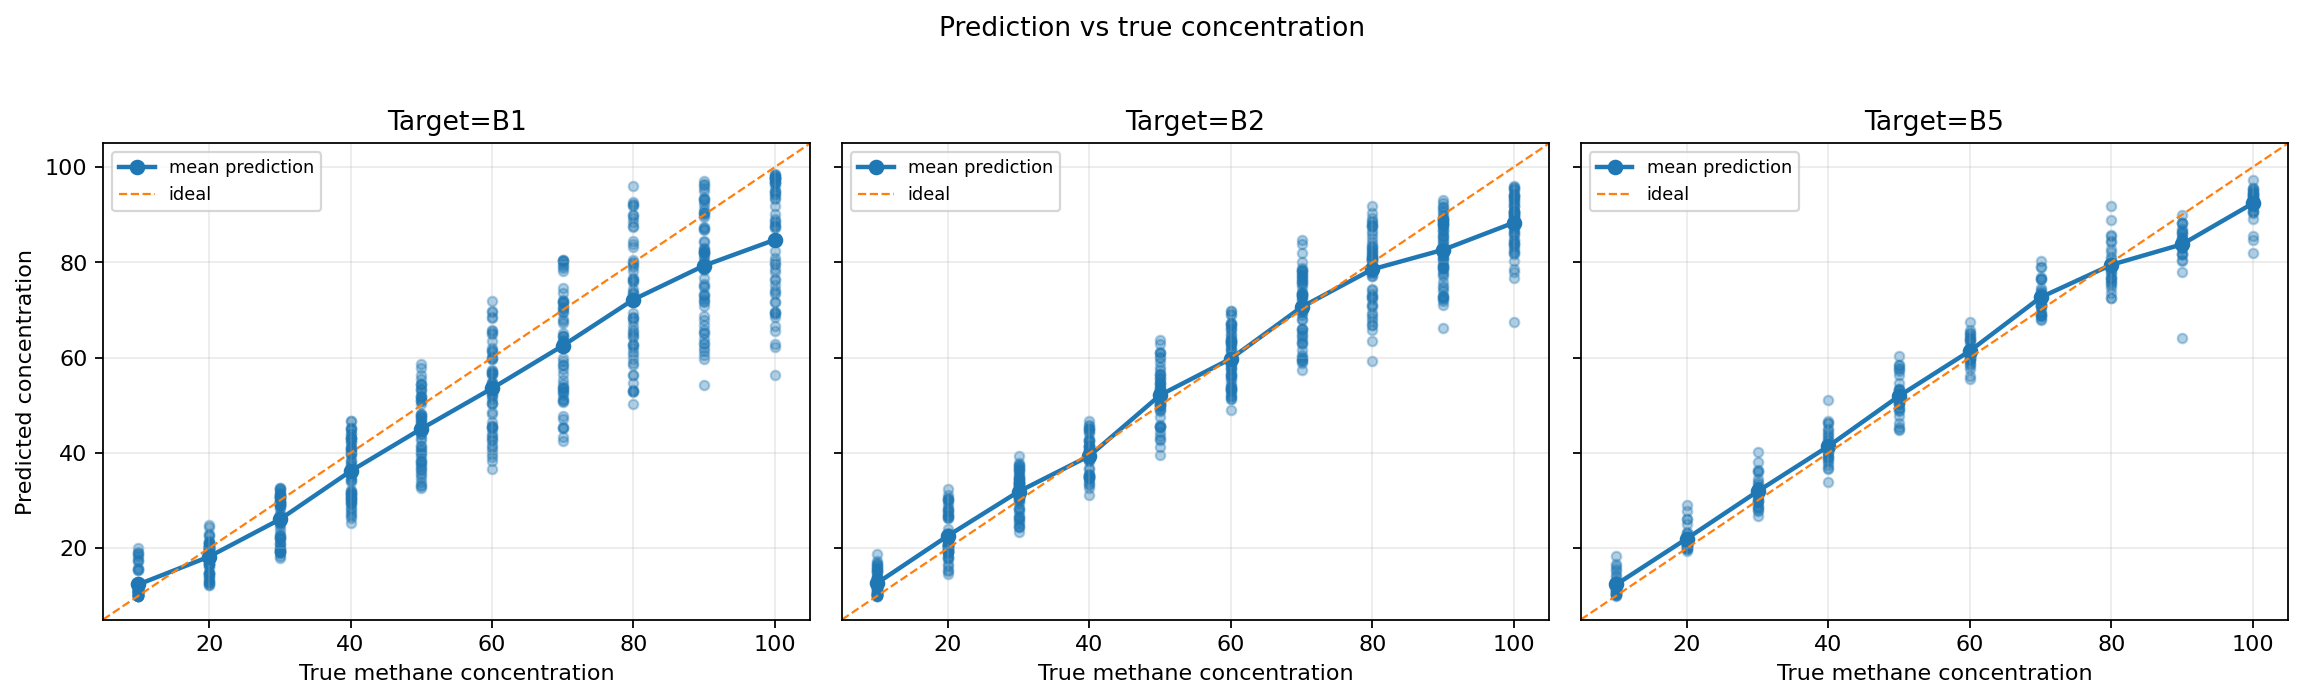

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\prediction_vs_true_B1_B2_B5.png


In [6]:
def _prediction_vs_true_by_target(pred_df, path):
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), dpi=160, sharex=True, sharey=True)
    min_v = float(min(pred_df["y_true"].min(), pred_df["y_pred"].min()))
    max_v = float(max(pred_df["y_true"].max(), pred_df["y_pred"].max()))
    pad = 5
    for ax, target in zip(axes, TARGETS_FOR_COMPARISON):
        tmp = pred_df[pred_df["target_board"] == target].copy()
        ax.scatter(tmp["y_true"], tmp["y_pred"], alpha=0.35, s=18)
        mean_pred = tmp.groupby("y_true", as_index=False)["y_pred"].mean()
        ax.plot(mean_pred["y_true"], mean_pred["y_pred"], marker="o", linewidth=2, label="mean prediction")
        ax.plot([min_v - pad, max_v + pad], [min_v - pad, max_v + pad], linestyle="--", linewidth=1, label="ideal")
        ax.set_title(f"Target={target}")
        ax.set_xlabel("True methane concentration")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("Predicted concentration")
    for ax in axes:
        ax.set_xlim(min_v - pad, max_v + pad)
        ax.set_ylim(min_v - pad, max_v + pad)
    fig.suptitle("Prediction vs true concentration", y=1.03)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.show()

pred_true_path = FIG_DIR / "prediction_vs_true_B1_B2_B5.png"
_prediction_vs_true_by_target(pred_df, pred_true_path)
print("Saved:", pred_true_path)


## 5. B1 single-source failure cases

The previous two plots used all source combinations. This section isolates the clearest B1 single-source failures.

We focus on:

- B3 → B1
- B4 → B1
- B5 → B1

If these all show similar high-concentration compression, the failure is more likely target-intrinsic. If only one source shows it, the failure is more likely a source-target mismatch.


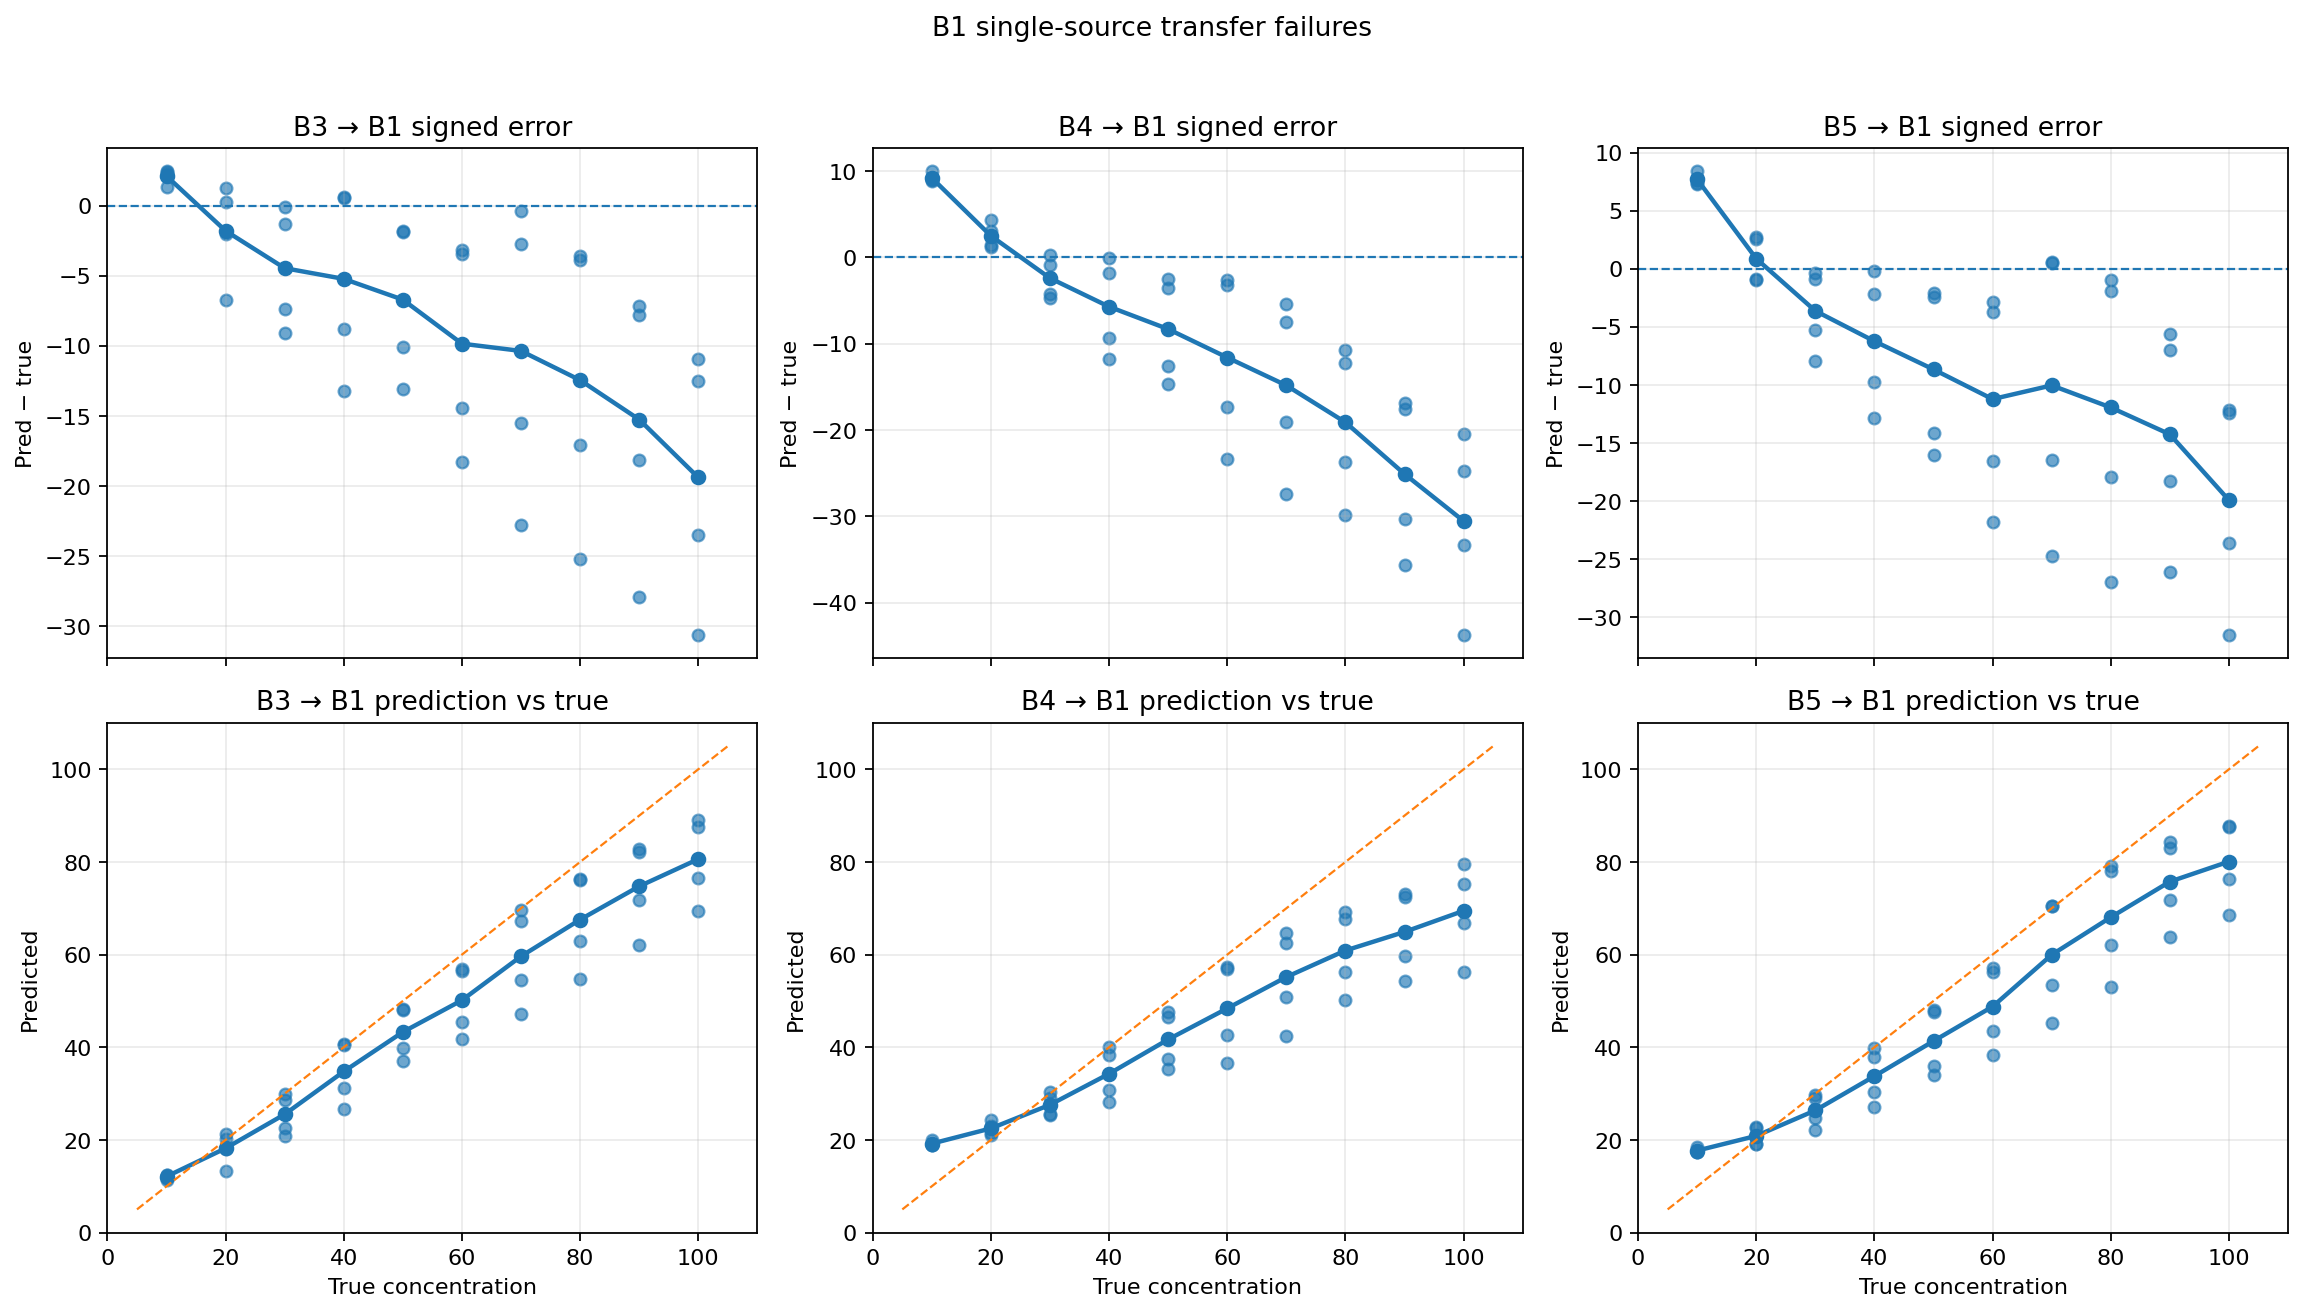

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\b1_single_source_signed_error_and_prediction_vs_true.png


,source_boards,n_source_boards,target_board,feature_set,model,n_train,n_test,rmse,mae,r2,includes_B5_source,source_count
2,B4,1,B1,physics,RandomForest,20,40,17.059493,12.948750,0.647241,False,1
3,B5,1,B1,physics,RandomForest,20,40,12.973678,9.587500,0.795980,True,1
1,B3,1,B1,physics,RandomForest,40,40,12.264505,8.894375,0.817675,False,1
0,B2,1,B1,physics,RandomForest,40,40,8.160622,6.738750,0.919278,False,1


In [7]:
b1_single = pred_df[
    (pred_df["target_board"] == "B1")
    & (pred_df["source_boards"].isin(B1_KEY_FAILURE_SOURCES))
    & (pred_df["source_count"] == 1)
].copy()

if b1_single.empty:
    raise ValueError("No B1 single-source predictions found. Check source_boards format in pred_df.")

fig, axes = plt.subplots(2, 3, figsize=(14.5, 8.0), dpi=160, sharex="col")
for j, source in enumerate(B1_KEY_FAILURE_SOURCES):
    tmp = b1_single[b1_single["source_boards"] == source].copy()
    ax = axes[0, j]
    ax.scatter(tmp["y_true"], tmp["signed_error"], alpha=0.65, s=28)
    bias = tmp.groupby("y_true", as_index=False)["signed_error"].mean()
    ax.plot(bias["y_true"], bias["signed_error"], marker="o", linewidth=2)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{source} → B1 signed error")
    ax.set_ylabel("Pred − true")
    ax.grid(alpha=0.25)

    ax = axes[1, j]
    ax.scatter(tmp["y_true"], tmp["y_pred"], alpha=0.65, s=28)
    mean_pred = tmp.groupby("y_true", as_index=False)["y_pred"].mean()
    ax.plot(mean_pred["y_true"], mean_pred["y_pred"], marker="o", linewidth=2)
    lo = min(tmp["y_true"].min(), tmp["y_pred"].min()) - 5
    hi = max(tmp["y_true"].max(), tmp["y_pred"].max()) + 5
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
    ax.set_title(f"{source} → B1 prediction vs true")
    ax.set_xlabel("True concentration")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.25)

fig.suptitle("B1 single-source transfer failures", y=1.02)
fig.tight_layout()
b1_single_path = FIG_DIR / "b1_single_source_signed_error_and_prediction_vs_true.png"
fig.savefig(b1_single_path, bbox_inches="tight")
plt.show()
print("Saved:", b1_single_path)

display(metrics_df[(metrics_df["target_board"] == "B1") & (metrics_df["source_count"] == 1)].sort_values("rmse", ascending=False))


## 6. Concentration-specific bias and MAE

This table and plot quantify the concentration regime where the B1 failure appears. The key comparison is high concentration (≥80) versus low/mid concentration.


Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2_5_b1_failure\day2_5_bias_by_concentration.csv
Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2_5_b1_failure\day2_5_regime_error_summary.csv


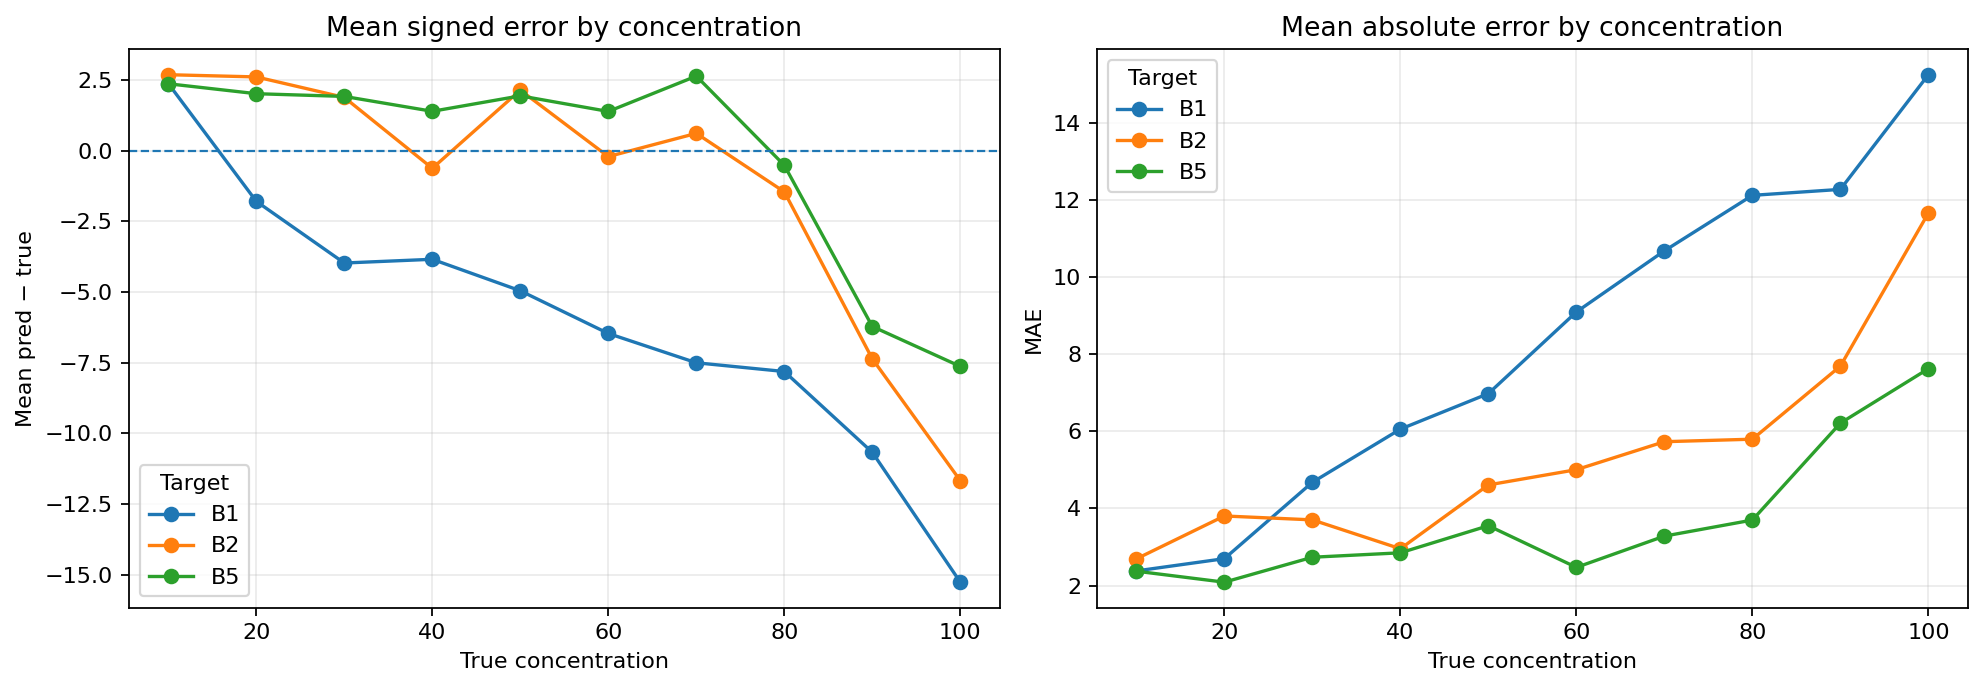

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\concentration_specific_bias_and_mae_B1_B2_B5.png


,target_board,source_boards,source_count,regime,mae,bias,pred_mean,n
0,B1,B2,1,high_>=80,9.375000,-4.145833,85.854167,12
1,B1,B2,1,low_<=30,3.337500,1.637500,21.637500,12
2,B1,B2,1,mid_40_70,7.312500,-1.568750,53.431250,16
24,B1,B3,1,high_>=80,15.697917,-15.697917,74.302083,12
25,B1,B3,1,low_<=30,3.041667,-1.391667,18.608333,12
26,B1,B3,1,mid_40_70,8.181250,-8.040625,46.959375,16
36,B1,B4,1,high_>=80,24.920833,-24.920833,65.079167,12
37,B1,B4,1,low_<=30,4.750000,3.091667,23.091667,12
38,B1,B4,1,mid_40_70,10.118750,-10.118750,44.881250,16
42,B1,B5,1,high_>=80,15.368750,-15.368750,74.631250,12


In [8]:
bias_by_conc = (
    pred_df.groupby(["target_board", "source_boards", "source_count", "y_true"], as_index=False)
    .agg(
        mean_signed_error=("signed_error", "mean"),
        median_signed_error=("signed_error", "median"),
        mae=("abs_error", "mean"),
        pred_mean=("y_pred", "mean"),
        n=("signed_error", "size"),
    )
)

bias_csv = RESULT_DIR / "day2_5_bias_by_concentration.csv"
bias_by_conc.to_csv(bias_csv, index=False)
print("Saved:", bias_csv)

def _regime(v):
    if v <= 30:
        return "low_<=30"
    if v <= 70:
        return "mid_40_70"
    return "high_>=80"

pred_df["regime"] = pred_df["y_true"].map(_regime)
regime_summary = (
    pred_df.groupby(["target_board", "source_boards", "source_count", "regime"], as_index=False)
    .agg(
        mae=("abs_error", "mean"),
        bias=("signed_error", "mean"),
        pred_mean=("y_pred", "mean"),
        n=("signed_error", "size"),
    )
)
regime_csv = RESULT_DIR / "day2_5_regime_error_summary.csv"
regime_summary.to_csv(regime_csv, index=False)
print("Saved:", regime_csv)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), dpi=160)
for target in TARGETS_FOR_COMPARISON:
    tmp = bias_by_conc[bias_by_conc["target_board"] == target]
    mean_tmp = tmp.groupby("y_true", as_index=False).agg(
        mean_bias=("mean_signed_error", "mean"),
        mean_mae=("mae", "mean"),
    )
    axes[0].plot(mean_tmp["y_true"], mean_tmp["mean_bias"], marker="o", label=target)
    axes[1].plot(mean_tmp["y_true"], mean_tmp["mean_mae"], marker="o", label=target)
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title("Mean signed error by concentration")
axes[0].set_xlabel("True concentration")
axes[0].set_ylabel("Mean pred − true")
axes[1].set_title("Mean absolute error by concentration")
axes[1].set_xlabel("True concentration")
axes[1].set_ylabel("MAE")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(title="Target")
fig.tight_layout()
conc_bias_path = FIG_DIR / "concentration_specific_bias_and_mae_B1_B2_B5.png"
fig.savefig(conc_bias_path, bbox_inches="tight")
plt.show()
print("Saved:", conc_bias_path)

display(regime_summary[regime_summary["target_board"].eq("B1")].sort_values(["source_count", "source_boards", "regime"]))


## 7. Does adding source boards fix B1?

If B1 is mainly source-selection limited, then using more source boards should consistently reduce B1 RMSE.

If B1 is target-intrinsic, then RMSE may remain high even as the number of source boards increases.


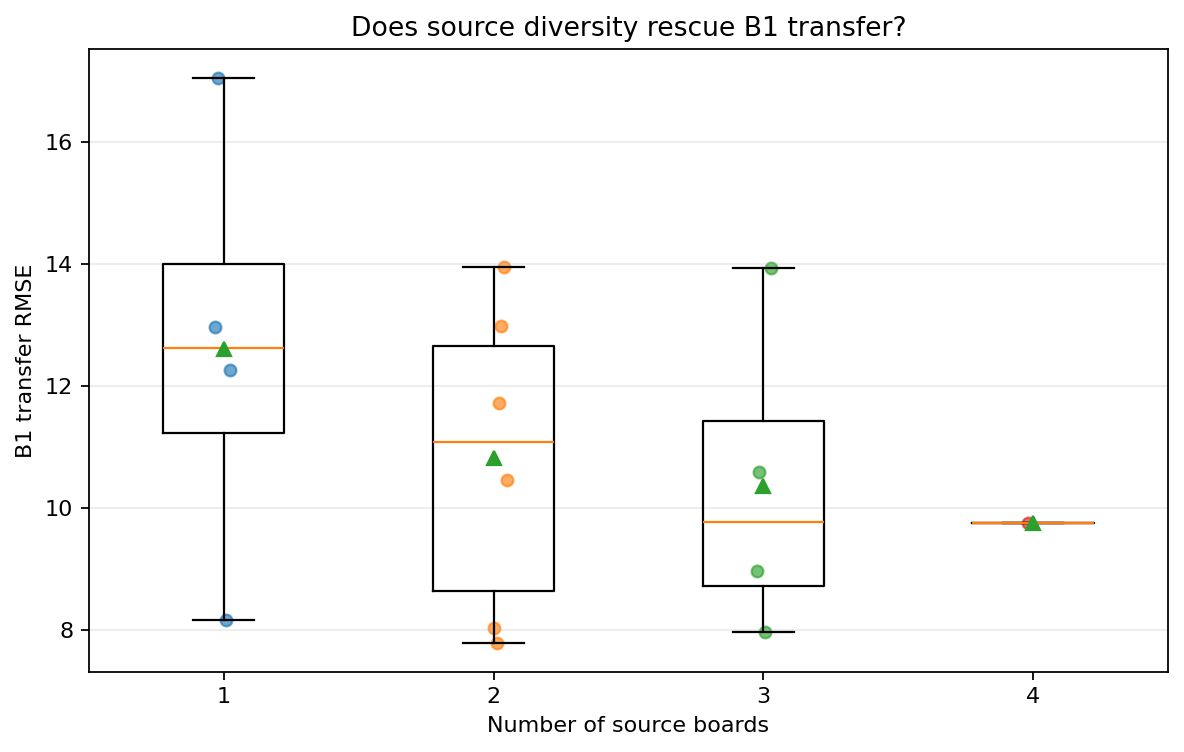

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\b1_rmse_by_source_count.png


,source_boards,n_source_boards,target_board,feature_set,model,n_train,n_test,rmse,mae,r2,includes_B5_source,source_count
0,B2,1,B1,physics,RandomForest,40,40,8.160622,6.738750,0.919278,False,1
1,B3,1,B1,physics,RandomForest,40,40,12.264505,8.894375,0.817675,False,1
3,B5,1,B1,physics,RandomForest,20,40,12.973678,9.587500,0.795980,True,1
2,B4,1,B1,physics,RandomForest,20,40,17.059493,12.948750,0.647241,False,1
6,B2+B5,2,B1,physics,RandomForest,60,40,7.782574,6.320625,0.926584,True,2
5,B2+B4,2,B1,physics,RandomForest,60,40,8.025199,6.536250,0.921935,False,2
4,B2+B3,2,B1,physics,RandomForest,80,40,10.454833,7.156250,0.867511,False,2
9,B4+B5,2,B1,physics,RandomForest,40,40,11.720415,8.108750,0.833493,True,2
8,B3+B5,2,B1,physics,RandomForest,60,40,12.979962,9.661875,0.795783,True,2
7,B3+B4,2,B1,physics,RandomForest,60,40,13.946360,10.161250,0.764241,False,2


In [9]:
b1_metrics = metrics_df[metrics_df["target_board"] == "B1"].copy()

fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=160)
source_counts = sorted(b1_metrics["source_count"].unique())
plot_data = [b1_metrics.loc[b1_metrics["source_count"] == k, "rmse"].values for k in source_counts]
ax.boxplot(plot_data, labels=source_counts, showmeans=True)
for i, k in enumerate(source_counts, start=1):
    vals = b1_metrics.loc[b1_metrics["source_count"] == k, "rmse"].values
    x = np.full(len(vals), i) + np.random.default_rng(RANDOM_STATE + k).normal(0, 0.035, len(vals))
    ax.scatter(x, vals, alpha=0.65, s=28)
ax.set_xlabel("Number of source boards")
ax.set_ylabel("B1 transfer RMSE")
ax.set_title("Does source diversity rescue B1 transfer?")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
b1_source_count_path = FIG_DIR / "b1_rmse_by_source_count.png"
fig.savefig(b1_source_count_path, bbox_inches="tight")
plt.show()
print("Saved:", b1_source_count_path)

display(b1_metrics.sort_values(["source_count", "rmse"]))


## 8. Physics-feature diagnosis: baseline, response, and recovery structure

Geometry metrics alone did not explain B1. We now inspect the physics-informed feature families directly.

The goal is not to prove causality, but to determine whether B1 differs mainly in:

- baseline level,
- response amplitude / sensitivity,
- early response slope,
- late recovery slope,
- recovery residual.

A B1-specific anomaly in response or recovery features would support a target-side dynamics explanation.


{'baseline': 10, 'early_slope': 8, 'late_slope': 8, 'recovery': 18, 'response': 27}
Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2_5_b1_failure\day2_5_physics_family_summary.csv


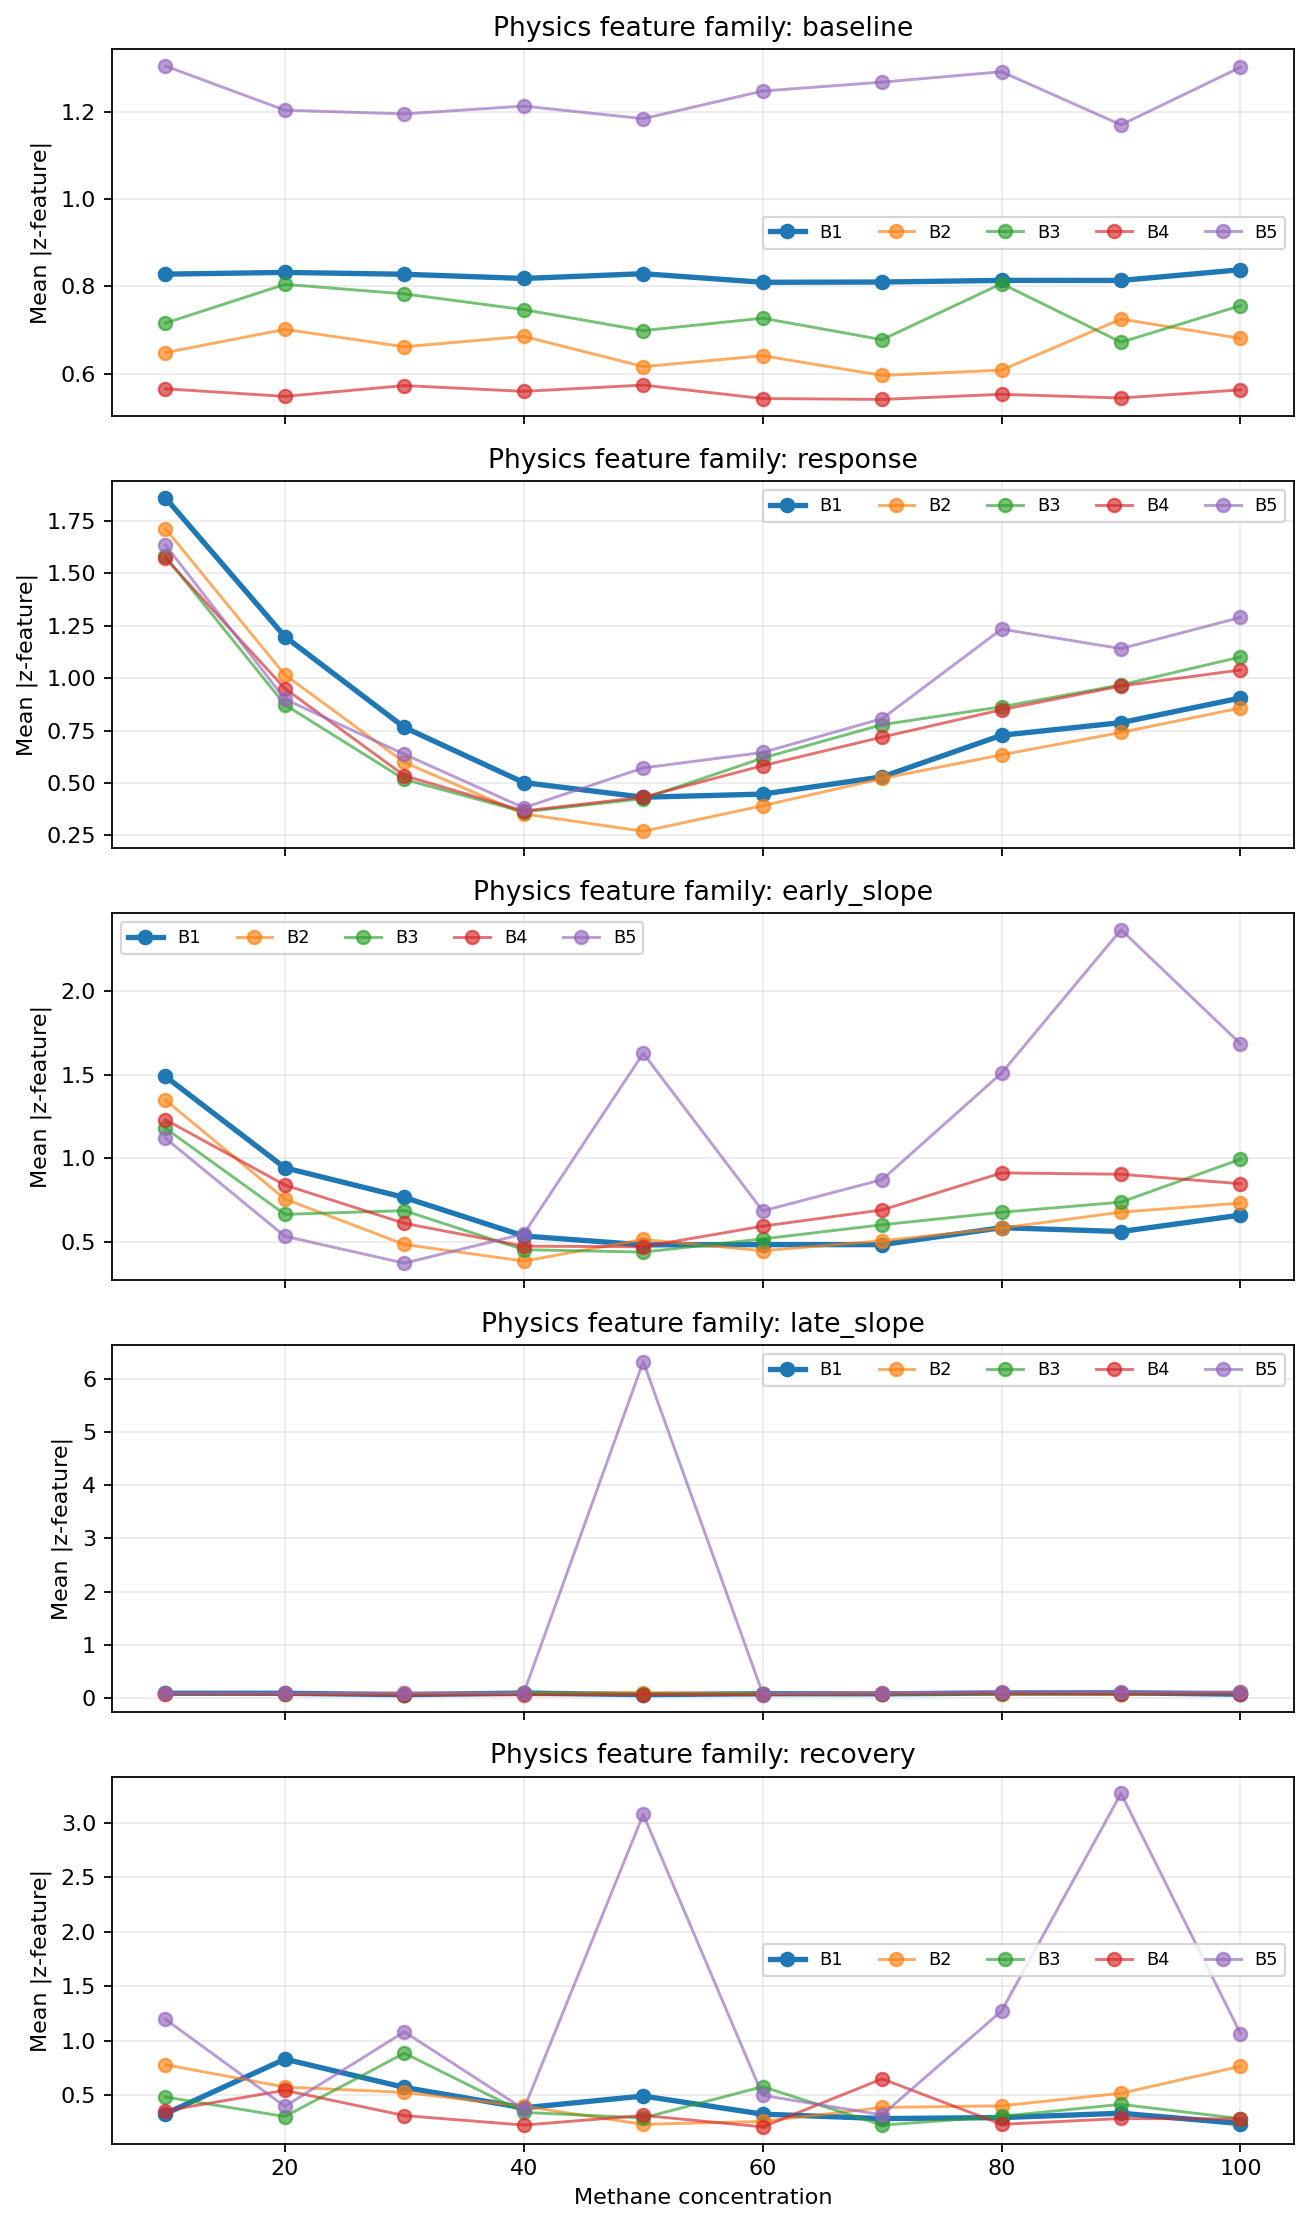

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\physics_feature_family_by_board_and_concentration.png


In [10]:
def _feature_family(col):
    if "baseline" in col:
        return "baseline"
    if "response_abs" in col or "response_norm" in col or "sensitivity_ratio" in col or "phys_response_" in col:
        return "response"
    if "early_slope" in col:
        return "early_slope"
    if "late_slope" in col:
        return "late_slope"
    if "recovery" in col:
        return "recovery"
    return "other"

family_map = {c: _feature_family(c) for c in feature_cols}
family_cols = {fam: [c for c, f in family_map.items() if f == fam] for fam in sorted(set(family_map.values()))}
print({k: len(v) for k, v in family_cols.items()})

# Robust standardized magnitude by board/concentration/family.
X = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float)
Xz = pd.DataFrame(StandardScaler().fit_transform(X), columns=feature_cols, index=df.index)
phys_summary_rows = []
for fam, cols in family_cols.items():
    if not cols or fam == "other":
        continue
    mag = Xz[cols].abs().mean(axis=1)
    tmp = df[["board", "concentration_numeric", "sample_id"]].copy()
    tmp["family"] = fam
    tmp["standardized_abs_magnitude"] = mag.values
    phys_summary_rows.append(tmp)
phys_long = pd.concat(phys_summary_rows, ignore_index=True)

phys_board_summary = (
    phys_long.groupby(["board", "concentration_numeric", "family"], as_index=False)
    .agg(mean_magnitude=("standardized_abs_magnitude", "mean"), n=("standardized_abs_magnitude", "size"))
)
phys_csv = RESULT_DIR / "day2_5_physics_family_summary.csv"
phys_board_summary.to_csv(phys_csv, index=False)
print("Saved:", phys_csv)

families_to_plot = [f for f in ["baseline", "response", "early_slope", "late_slope", "recovery"] if f in phys_board_summary["family"].unique()]
fig, axes = plt.subplots(len(families_to_plot), 1, figsize=(8.2, 2.8 * len(families_to_plot)), dpi=160, sharex=True)
if len(families_to_plot) == 1:
    axes = [axes]
for ax, fam in zip(axes, families_to_plot):
    tmp = phys_board_summary[phys_board_summary["family"] == fam]
    for board, part in tmp.groupby("board"):
        linewidth = 2.4 if board == "B1" else 1.3
        alpha = 1.0 if board == "B1" else 0.65
        ax.plot(part["concentration_numeric"], part["mean_magnitude"], marker="o", label=board, linewidth=linewidth, alpha=alpha)
    ax.set_title(f"Physics feature family: {fam}")
    ax.set_ylabel("Mean |z-feature|")
    ax.grid(alpha=0.25)
    ax.legend(ncol=5, fontsize=8)
axes[-1].set_xlabel("Methane concentration")
fig.tight_layout()
phys_path = FIG_DIR / "physics_feature_family_by_board_and_concentration.png"
fig.savefig(phys_path, bbox_inches="tight")
plt.show()
print("Saved:", phys_path)


## 9. PCA view of B1 high-concentration regime

This final diagnostic checks whether B1 high-concentration samples occupy a distinct region in physics-feature space.

If B1 high-concentration points are separated from other boards, that supports a target-side regime shift. If they overlap strongly, the failure is more likely model/calibration rather than feature-space separation.


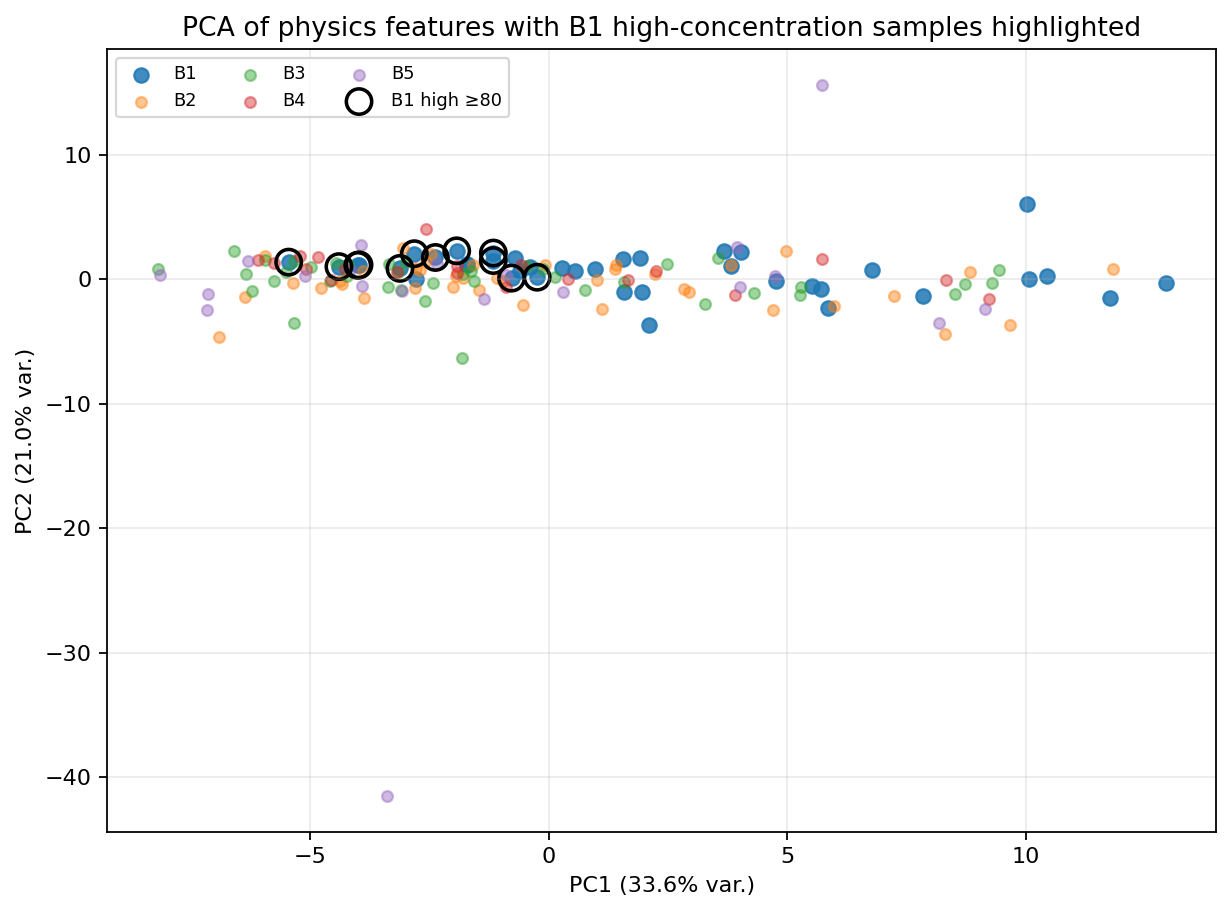

Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\pca_b1_high_concentration_highlighted.png
Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2_5_b1_failure\day2_5_pca_physics_features.csv


In [11]:
pca_cols = feature_cols
X = df[pca_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float)
Xs = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
emb = pca.fit_transform(Xs)
pca_df = df[["board", "concentration_numeric", "sample_id"]].copy()
pca_df["PC1"] = emb[:, 0]
pca_df["PC2"] = emb[:, 1]
pca_df["regime"] = pca_df["concentration_numeric"].map(_regime)
pca_df["is_B1_high"] = (pca_df["board"].eq("B1")) & (pca_df["regime"].eq("high_>=80"))

fig, ax = plt.subplots(figsize=(7.8, 5.8), dpi=160)
for board, part in pca_df.groupby("board"):
    alpha = 0.85 if board == "B1" else 0.45
    size = 42 if board == "B1" else 24
    ax.scatter(part["PC1"], part["PC2"], label=board, alpha=alpha, s=size)

b1_high = pca_df[pca_df["is_B1_high"]]
ax.scatter(b1_high["PC1"], b1_high["PC2"], s=130, facecolors="none", edgecolors="black", linewidths=1.6, label="B1 high ≥80")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.set_title("PCA of physics features with B1 high-concentration samples highlighted")
ax.legend(ncol=3, fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
pca_path = FIG_DIR / "pca_b1_high_concentration_highlighted.png"
fig.savefig(pca_path, bbox_inches="tight")
plt.show()
print("Saved:", pca_path)

pca_csv = RESULT_DIR / "day2_5_pca_physics_features.csv"
pca_df.to_csv(pca_csv, index=False)
print("Saved:", pca_csv)


## 10. Failure-mode summary table

This notebook does not assume one universal transfer-failure mechanism. It explicitly separates two engineering cases:

| Failure mode | Representative target | Expected evidence | Practical implication |
|---|---|---|---|
| Coverage-limited transfer | B5 | Source coverage metrics reduce RMSE | Add diverse / representative source boards |
| Target-intrinsic nonlinear transfer | B1 | High-concentration bias/compression persists across source choices | Requires target-side correction, few-shot adaptation, or concentration-aware calibration |

Use the generated figures to decide which mechanism is supported for B1.


In [12]:
# Compact numerical summary for reporting.
summary_rows = []
for target in TARGETS_FOR_COMPARISON:
    tmp_pred = pred_df[pred_df["target_board"] == target].copy()
    tmp_metrics = metrics_df[metrics_df["target_board"] == target].copy()
    high = tmp_pred[tmp_pred["y_true"] >= 80]
    low_mid = tmp_pred[tmp_pred["y_true"] < 80]
    summary_rows.append({
        "target_board": target,
        "mean_rmse_all_source_sets": tmp_metrics["rmse"].mean(),
        "best_rmse": tmp_metrics["rmse"].min(),
        "worst_rmse": tmp_metrics["rmse"].max(),
        "mean_signed_error_all": tmp_pred["signed_error"].mean(),
        "mean_signed_error_high_ge80": high["signed_error"].mean(),
        "mae_high_ge80": high["abs_error"].mean(),
        "mae_low_mid_lt80": low_mid["abs_error"].mean(),
        "high_to_lowmid_mae_ratio": high["abs_error"].mean() / max(low_mid["abs_error"].mean(), 1e-12),
        "n_source_sets": tmp_metrics.shape[0],
    })
summary_df = pd.DataFrame(summary_rows)
summary_csv = RESULT_DIR / "day2_5_failure_mode_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)
display(summary_df)

print("\nGenerated figures:")
for p in sorted(FIG_DIR.glob("*.png")):
    print("-", p)
print("\nGenerated result files:")
for p in sorted(RESULT_DIR.glob("*.csv")):
    print("-", p)


Saved: C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2_5_b1_failure\day2_5_failure_mode_summary.csv


,target_board,mean_rmse_all_source_sets,best_rmse,worst_rmse,mean_signed_error_all,mean_signed_error_high_ge80,mae_high_ge80,mae_low_mid_lt80,high_to_lowmid_mae_ratio,n_source_sets
0,B1,11.105836,7.782574,17.059493,-5.986792,-11.245972,13.224861,6.084048,2.173695,15
1,B2,6.859121,4.451562,11.204104,-1.134875,-6.827917,8.388472,4.072738,2.059664,15
2,B5,4.644222,3.168976,9.522624,-0.066500,-4.785833,5.848056,2.763929,2.115849,15



Generated figures:
- C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\b1_rmse_by_source_count.png
- C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\b1_single_source_signed_error_and_prediction_vs_true.png
- C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\concentration_specific_bias_and_mae_B1_B2_B5.png
- C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\pca_b1_high_concentration_highlighted.png
- C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\physics_feature_family_by_board_and_concentration.png
- C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\prediction_vs_true_B1_B2_B5.png
- C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day2_5_b1_failure\signed_error_vs_true_concentration_B1_B2_B5.png

Generated result files:
- C:\Users\hg\PycharmProjects\mox_calibration_transfer\results\day2_5_b1_failu

## Interpretation notes to write after execution

After running the notebook, interpret B1 using the following decision logic:

1. **If B1 high-concentration signed error is strongly negative**  
   B1 failure is dominated by systematic high-concentration underestimation.

2. **If prediction-vs-true shows 80–100 ppm compressed toward 60–70 ppm**  
   B1 likely has target-side response compression. Source-domain coverage alone cannot fix this.

3. **If B1 RMSE remains high across 2-, 3-, and 4-source training**  
   B1 is not simply source-selection limited.

4. **If B1 physics-family curves diverge in response/recovery features**  
   The most plausible mechanism is dynamic mismatch or nonlinear saturation/recovery kinetics.

5. **If B1 looks normal in feature space but still has strong signed bias**  
   The problem is more likely calibration mapping bias than measurable physics-feature separation.

Recommended final wording if the evidence supports B1 target-side compression:

> B1 appears to represent a target-intrinsic high-concentration transfer failure. Unlike B5, whose error is reduced by broader source-domain coverage, B1's high-concentration error persists across source selections and is expressed as systematic prediction compression. This suggests that some cross-board failures cannot be solved by adding source diversity alone and require target-side correction or concentration-aware adaptation.
